# Tilt series generator

This notebook simulates a full cryoET tilt series end to end, in two stages:

1. **Specimen building** — `specter.pipelines.build_tomogram_generator` (the same code
   behind `specter build tomogram`) composites a real high-resolution scattering
   potential: densely packed protein species (RSA hard-sphere packing, region-gated to
   cytosol/lumen when a membrane is present) plus an optional organic membrane. See
   `tomogram.toml` in this folder for the specimen config, and
   `specter.specimen.tomogram.TomogramSpecimenGenerator`'s own docstring for the full
   algorithm.
2. **Imaging** — `TiltSeriesGenerator` takes the assembled volume, blends in amorphous
   ice, then simulates the real tilted acquisition: multislice scattering per tilt
   angle, CTF, dose, detector MTF, and Poisson shot noise. Reconstruction-facing
   artifacts like the missing wedge come from the tilt range itself -- real
   reconstruction still has to happen downstream (e.g. IMOD), since this class only
   simulates the forward tilt series.

For a from-the-command-line version of this same two-stage pipeline, run
`specter build tomogram` followed by `specter simulate tiltseries`.

In [1]:
import logging
import time

import matplotlib.pyplot as plt
import torch

import specter
from specter.config import load_config, TiltSeriesConfig, TomogramConfig
from specter.plots import plot3d, plot_particle_stack
from specter.pipelines import build_tomogram_generator
from specter.imagegenerator import TiltSeriesGenerator

%load_ext autoreload
%autoreload 2

In [6]:
tomogram_config = load_config("tomogram.toml", TomogramConfig)
config = load_config("tilt_series.toml", TiltSeriesConfig)

In [3]:
specter.set_verbosity(logging.INFO)

## Build the specimen

`tomogram_config` comes from `tomogram.toml`'s `[targets]`/`[filler]`/`[[membrane]]` tables --
densely packed protein species (RSA hard-sphere packing), region-gated to cytosol/lumen when a
membrane is present, plus an optional organic membrane. `filler_from_pei2016`/
`filler_from_cryoetsim` (off by default here) pull in generic cytosolic crowding from a
published reference table, to avoid an unrealistically empty/flat background around the
annotated targets.

`tomogram_config.target_shape`/`voxel_size` is the real output volume, `(Z, Y, X)` voxels at the
given Å/voxel -- `config.voxel_size` (`tilt_series.toml`, used below) must match it.

In [7]:
gen = build_tomogram_generator(tomogram_config)

## Generate

Runs RSA hard-sphere packing (and any organic membrane), then renders every placed instance's
real scattering potential. Returns a `torch.Tensor`, specter-native axis order `(Z, Y, X)` --
the same volume `specter build tomogram` would write to `.mrc`.

In [8]:
t0 = time.time()
volume = gen.generate()
print(f"generated in {time.time() - t0:.1f}s")
print(
    "shape:",
    tuple(volume.shape),
    "nonzero voxels:",
    int((volume > 0).sum()),
    "max:",
    float(volume.max()),
)

──────────────────────────────────────────────────── Membranes ────────────────────────────────────────────────────

Placing 1 membrane instance(s): 00:00

Generating membrane instances:   0%|          | 0/1 [00:00<?, ?it/s]

Membranes (1 instance(s)): 0s


───────────────────────────────────────────── Fetching PDB structures ─────────────────────────────────────────────

...

  Target packing (cytosol): 0s


/tmp/ipykernel_235925/1682773024.py:2: UserWarning: TomogramSpecimenGenerator: only 5/7 exact-count instances fit in the 'cytosol' region without colliding -- it may be too small or too crowded for the requested n_copies.
  volume = gen.generate()


Rendering species templates (cytosol, target):   0%|          | 0/4 [00:00<?, ?it/s]

Placing species (cytosol, target):   0%|          | 0/4 [00:00<?, ?it/s]

  Target rendering (cytosol): 1s
  Exclusion field rebuild (cytosol): 0s
Cytosol species: 1s
generated in 26.0s
shape: (64, 160, 160) nonzero voxels: 120011 max: 10.286514282226562


## Visualize

Central slice through Z, and a 3D rendering.

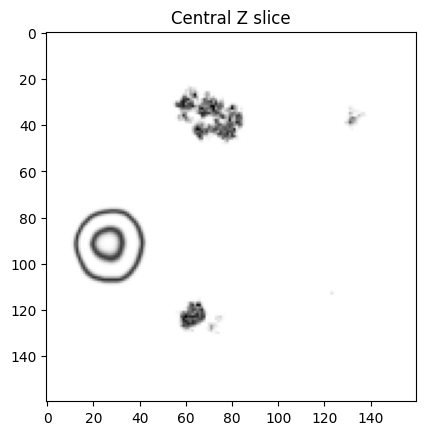

In [9]:
plt.imshow(-volume[volume.shape[0] // 2], cmap="grey")
plt.title("Central Z slice")
plt.show()

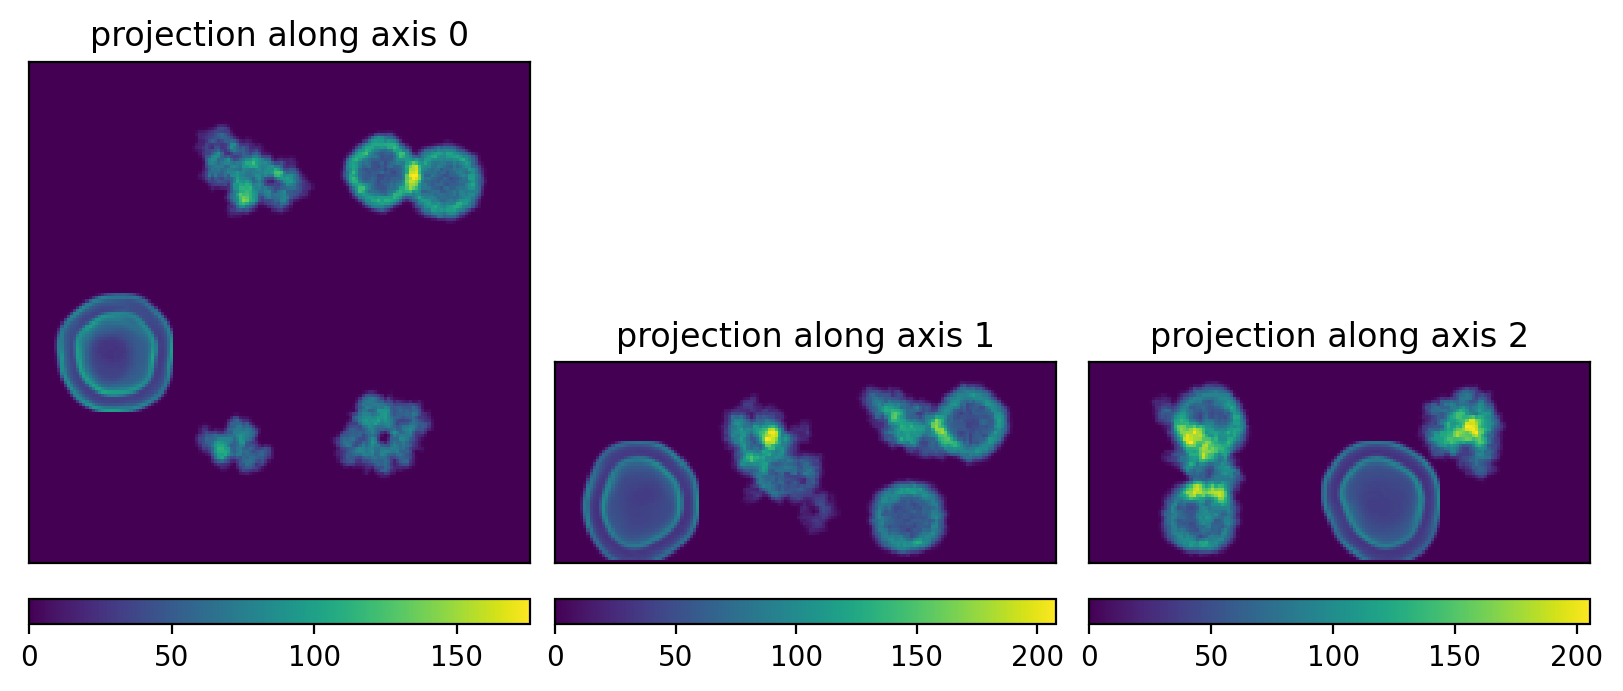

In [10]:
plot3d(volume)

## Simulate a tilt series

`TiltSeriesGenerator` takes the assembled `volume` directly (reshaped to its expected
`(1, Z, Y, X)`), blends in amorphous ice, then simulates the real acquisition: multislice
scattering per tilt angle, CTF, dose, detector MTF, and Poisson shot noise — reconstruction-facing
artifacts like the missing wedge come from the tilt range itself (real reconstruction still has
to happen downstream, e.g. IMOD, since this class only simulates the forward tilt series).

`ice_model="gd"` uses `IceBank`, which samples from the bundled cache of pre-generated,
physically-relaxed ice configs (`ice-data/ice_cache`) rather than generating fresh ice on the
spot — this is the realistic option; `"random"` is a cheap/fast placeholder with no real physical
structure, useful only for quick smoke tests.

`micrograph_size` and `pixel_size` are read from `config`/the generated `volume` rather than
hardcoded, so this cell adapts automatically if you change `target_shape`/`voxel_size` in
`tilt_series.toml`.

In [11]:
micrograph_size = (
    config.micrograph_size
    if config.micrograph_size is not None
    else int(volume.shape[-1])
)
pixel_size = config.voxel_size

angles = torch.linspace(config.min_tilt_angle, config.max_tilt_angle, config.n_tilts)

cs_angstrom = config.cs * 1e7  # mm -> Å
cc_angstrom = config.cc * 1e7 if config.cc is not None else None

ctf_params = {
    "cs": torch.tensor([cs_angstrom]),
    "dfu": torch.tensor([config.defocus]),
}

ice_model = None if config.ice_model == "none" else config.ice_model
# ice_model = None
noise_model = None if config.noise_model == "none" else config.noise_model
# noise_model = None
detector_model = None if config.detector_model == "none" else config.detector_model

tilt_series_gen = TiltSeriesGenerator(
    vol=volume.unsqueeze(0),  # (1, Z, Y, X)
    micrograph_size=micrograph_size,
    pixel_size=pixel_size,
    ctf_params=ctf_params,
    voltage=config.voltage,
    dose_per_angstrom=config.dose_per_tilt,
    angles=angles,
    ice_model=ice_model,
    ice_cache_dir=config.ice_cache_dir,
    # ice_relax_steps=config.ice_relax_steps,
    ice_relax_steps=2,
    scattering_model=config.scattering_model,
    aberration_model=config.aberration_model,
    noise_model=noise_model,
    alpha=config.alpha,
    pad_fft=config.pad_fft,
    tilt_axis=config.tilt_axis,
    coincidence_radius=config.coincidence_radius,
    n_frames=config.n_frames,
    convergence_angle=config.convergence_angle,
    cc=cc_angstrom,
    energy_spread=config.energy_spread,
    deltaV_V=config.deltaV_V,
    deltaI_I=config.deltaI_I,
    dose_envelope=config.dose_envelope,
    detector_model=detector_model,
)

[TiltSeriesGenerator] Adding ice to volume using gd model


Tiling ice volume: 00:00

Placing ice tiles:   0%|          | 0/32 [00:00<?, ?it/s]

Relaxing tile seams:   0%|          | 0/2 [00:00<?, ?it/s]

[TiltSeriesGenerator] Volume XY too small for requested tilt coverage; padded (reflect) from 160 to 308 px in XY.
  micrograph_size=160, requested_max_tilt=45.00 deg, required_volume_nxy>=291, edge_margin=8 (-> required_nxy_padded>=307).


In [12]:
config.pad_fft

True

In [13]:
device = config.device
tilt_series_gen = tilt_series_gen.to(device)

t0 = time.time()
tilt_series, exitwaves, clean_images = tilt_series_gen.generate_tilt_series(
    torch.tensor([0])
)
print(f"generated in {time.time() - t0:.1f}s")
tilt_series.shape

Generating tilt series.:   0%|          | 0/5 [00:00<?, ?it/s]

Multislice (Iterative):   0%|          | 0/264 [00:00<?, ?it/s]

Multislice (Iterative):   0%|          | 0/177 [00:00<?, ?it/s]

Multislice (Iterative):   0%|          | 0/64 [00:00<?, ?it/s]

Multislice (Iterative):   0%|          | 0/177 [00:00<?, ?it/s]

Multislice (Iterative):   0%|          | 0/264 [00:00<?, ?it/s]

generated in 2.9s


torch.Size([1, 5, 160, 160])

## Visualize the tilt series

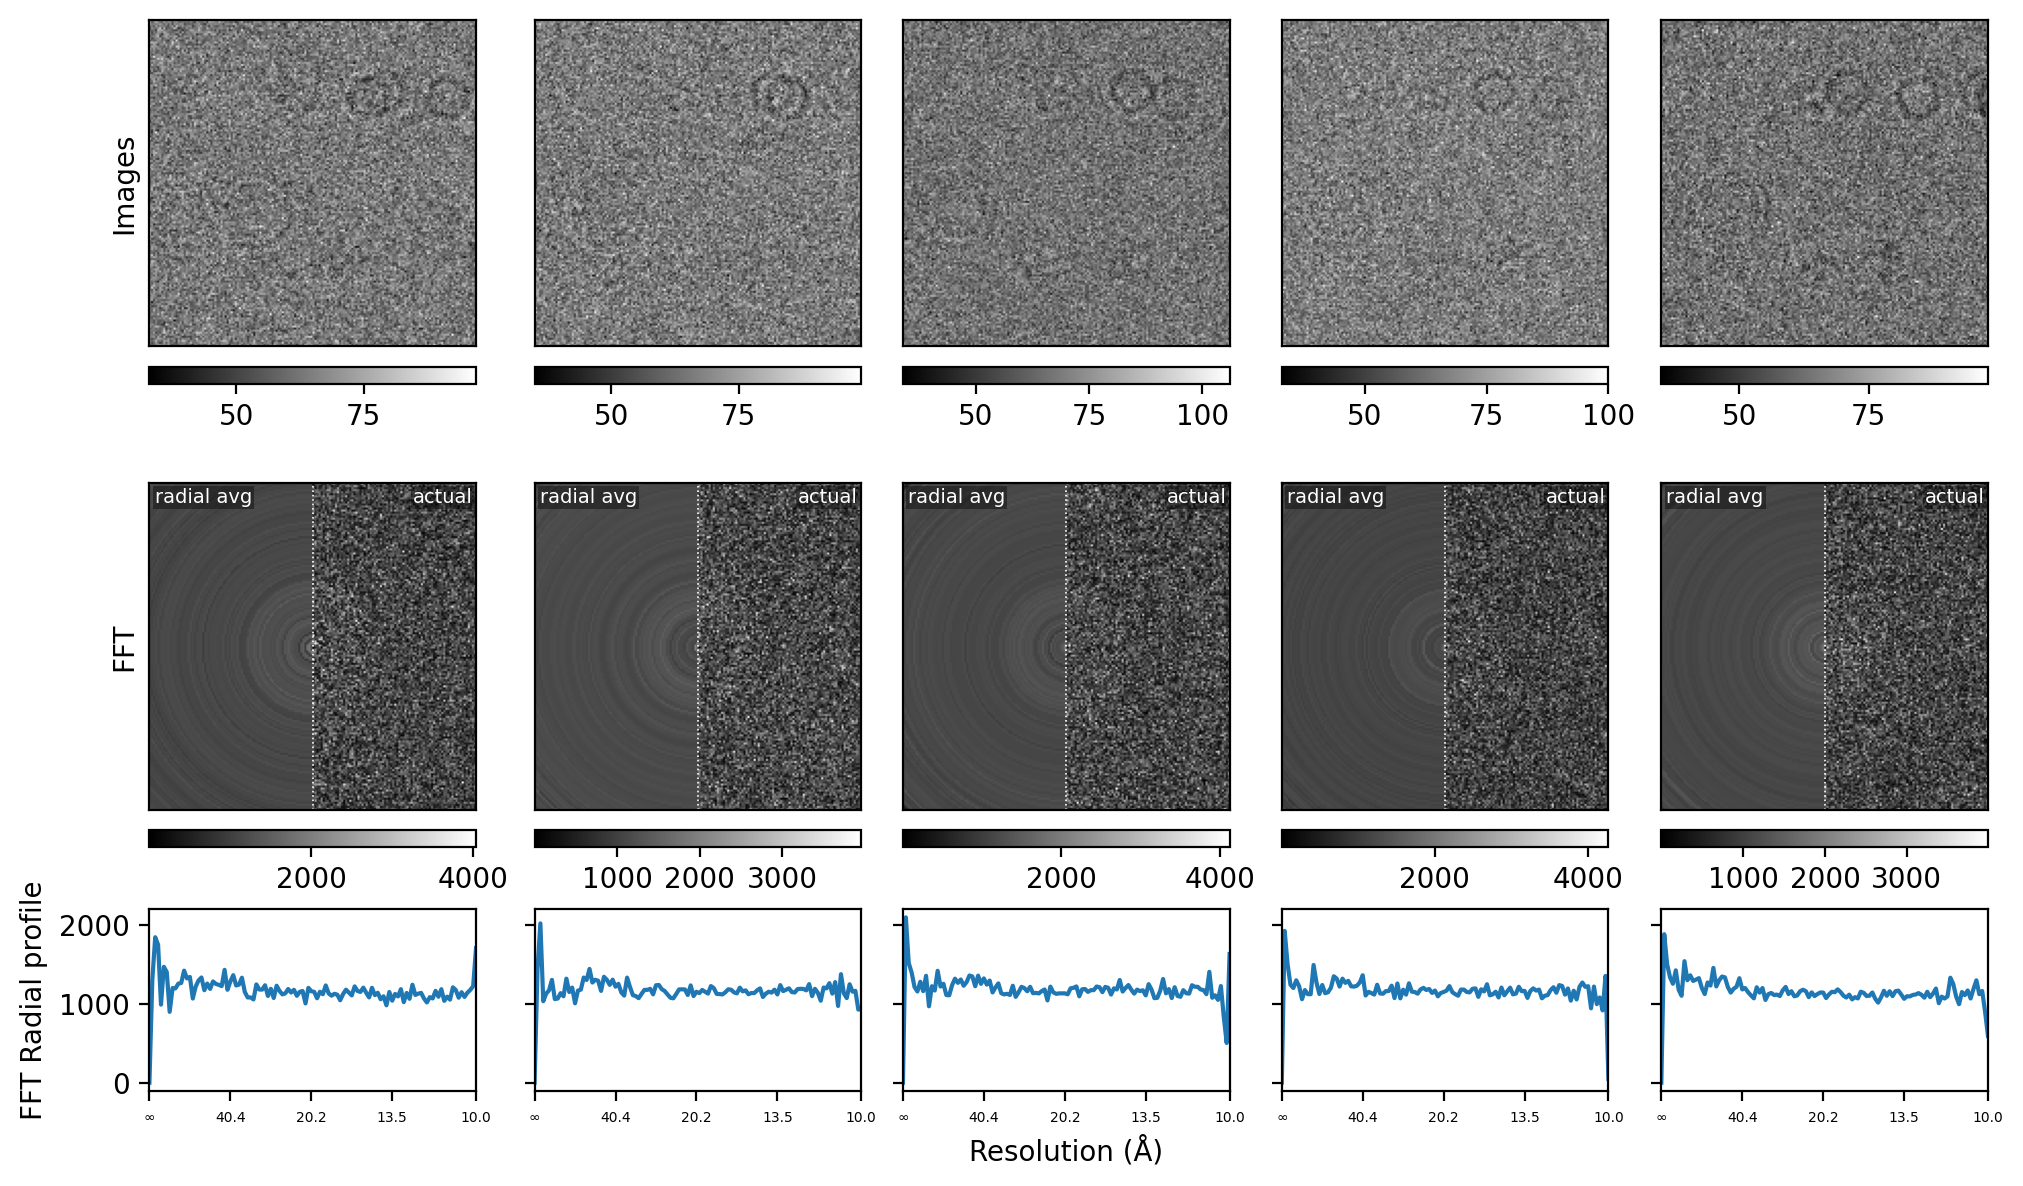

In [14]:
tilt_series_cpu = tilt_series[0].cpu()  # (n_tilts, H, W)

plot_particle_stack(tilt_series_cpu, config.voxel_size)